# Comparaison des modèles (Students Social Media Addiction)

**Dataset :** Mobile Addiction  
**Variable cible :** `Addiction_Level` score d'addiction (Low, Moderate, Severe, High)

Ce notebook charge les données, fait le preprocessing, puis appelle chaque modèle depuis le dossier `models/`.  
Il compare ensuite les résultats et propose un exemple d'application concret.

## 1 - Importation des bibliothèques

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append('..')

from sklearn.model_selection import train_test_split
from models.encoder import labelEncoder, oneHotEncoder

## 2 - Chargement et preprocessing

On charge le dataset, on supprime la colonne `User_ID` (identifiant sans valeur prédictive),  
et on convertit les variables textuelles en nombres avec `LabelEncoder`.  
Ensuite on sépare les données en 80% entraînement / 20% test.

In [ ]:
df = pd.read_csv('BDD_initial/mobile_addiction_data.csv', sep='\t')
df = df.drop(columns=['User_ID'])

X_raw = df.drop(columns=['Addiction_Level'])
y     = df['Addiction_Level']

# LabelEncoder
X_le  = labelEncoder(X_raw.copy())

# OneHotEncoder
X_ohe = oneHotEncoder(X_raw.copy())

# Split — même random_state pour comparer sur les mêmes données
X_train_le,  X_test_le,  y_train, y_test = train_test_split(X_le,  y, test_size=0.2, random_state=42)
X_train_ohe, X_test_ohe, _,       _      = train_test_split(X_ohe, y, test_size=0.2, random_state=42)

# label_encoders conservé pour l'exemple étudiant (cell 16)
from sklearn.preprocessing import LabelEncoder
cat_cols = df.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    le.fit(df[col])
    label_encoders[col] = le

print('X_le  shape:', X_le.shape)
print('X_ohe shape:', X_ohe.shape)
print('Train / Test:', X_train_le.shape[0], '/', X_test_le.shape[0])


X_le  shape: (3000, 33)
X_ohe shape: (3000, 22543)
Train / Test: 2400 / 600


## 4. Entraînement des modèles

Chaque modèle est dans un fichier séparé dans `models/`.  
La fonction `run(X_train, X_test, y_train, y_test)` retourne un dictionnaire avec les métriques.

> **Pour ajouter un modèle** : importer sa fonction `run` et l'ajouter au dictionnaire `modeles`.

In [32]:
import sys
sys.path.append('..')

from models.random_forest import run as run_rf
from models.xgboost import run as run_xgb

# autres modèles ici!!
# from models.knn import run as run_knn
# from models.decision_tree import run as run_dt
# from models.gradient_boosting import run as run_gb
# from models.naive_bayes import run as run_nb

modeles = {
    'Random Forest'     : run_rf,
    'XGBoost'          : run_xgb,
    # 'KNN'            : run_knn,
    # 'Decision Tree'  : run_dt,
    # 'Gradient Boosting': run_gb,
    # 'Naive Bayes'    : run_nb,
}

resultats = {}
for nom, run_fn in modeles.items():
    print(f"Entraînement : {nom}...")
    resultats[nom] = run_fn(X_train, X_test, y_train, y_test)
    print(f"  R² (optimisé) : {resultats[nom]['optimized']['r2']:.4f}")

print("\nTerminé.")

Entraînement : Random Forest...


ValueError: could not convert string to float: 'High'

## 5. Tableau comparatif

On compare les modèles sur trois métriques :
- **R²** : proportion de variance expliquée (plus c'est proche de 1, mieux c'est)
- **MAE** : erreur moyenne en points de score
- **RMSE** : similaire au MAE, mais pénalise plus les grandes erreurs

In [21]:
rows = []
for nom, res in resultats.items():
    opt = res['optimized']
    rows.append({
        'Modèle': nom,
        'R²'    : round(opt['r2'],   4),
        'MAE'   : round(opt['mae'],  4),
        'RMSE'  : round(opt['rmse'], 4),
    })

df_comparaison = pd.DataFrame(rows).sort_values('R²', ascending=False).set_index('Modèle')
df_comparaison

,R²,MAE,RMSE
Modèle,,,
XGBoost,-0.0046,1.1989,1.4344
Random Forest,-0.0053,1.2002,1.4348


## 6. Visualisation des métriques

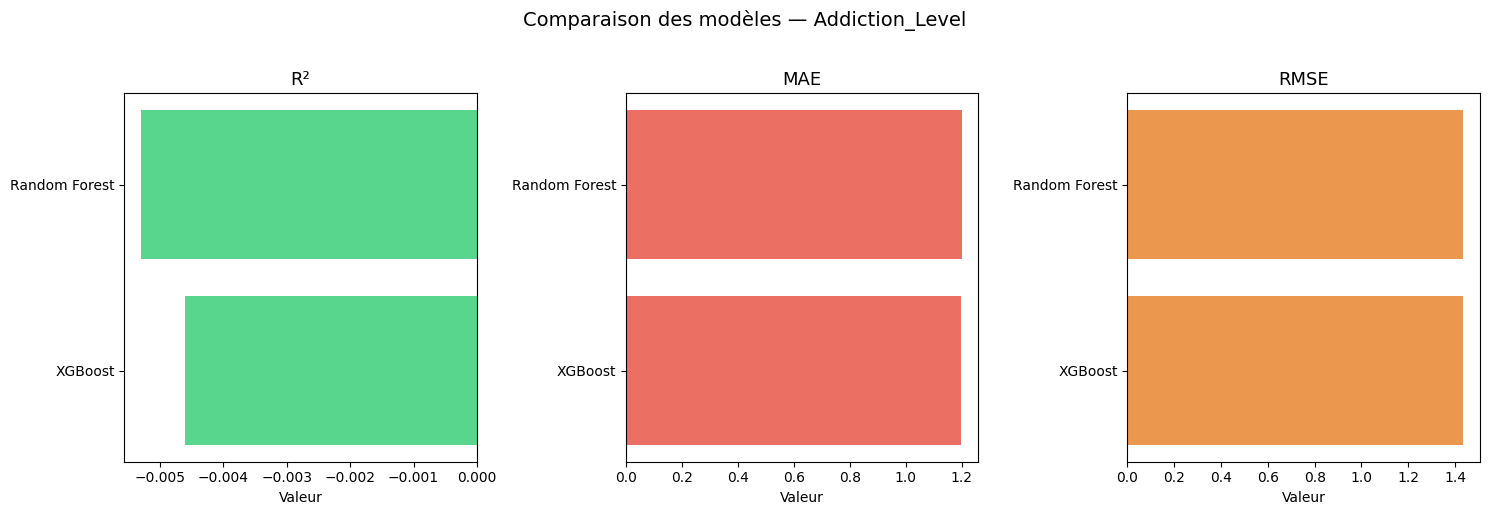

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [('R²', '#2ecc71', False), ('MAE', '#e74c3c', True), ('RMSE', '#e67e22', True)]

for ax, (metric, color, ascending) in zip(axes, metrics):
    vals = df_comparaison[metric].sort_values(ascending=ascending)
    ax.barh(vals.index, vals.values, color=color, alpha=0.8)
    ax.set_title(metric, fontsize=13)
    ax.set_xlabel('Valeur')

plt.suptitle('Comparaison des modèles — Addiction_Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7. Analyse détaillée : Random Forest

### Importance des variables

Le Random Forest calcule automatiquement l'importance de chaque variable :  
plus le score est élevé, plus la variable influence la prédiction.

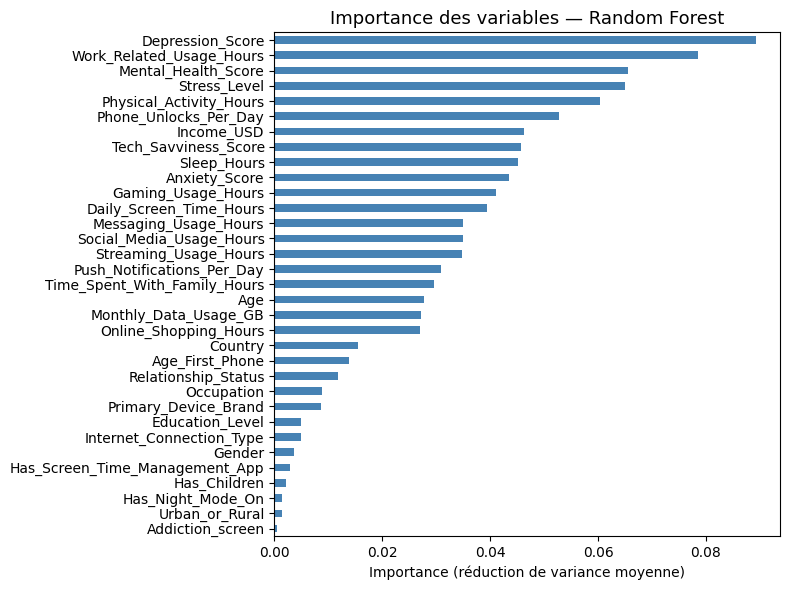

In [23]:
importances = resultats['Random Forest']['feature_importances']

fig, ax = plt.subplots(figsize=(8, 6))
importances.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Importance des variables — Random Forest', fontsize=13)
ax.set_xlabel('Importance (réduction de variance moyenne)')
plt.tight_layout()
plt.show()

### Valeurs réelles vs valeurs prédites

Un modèle parfait alignerait tous les points sur la diagonale rouge.

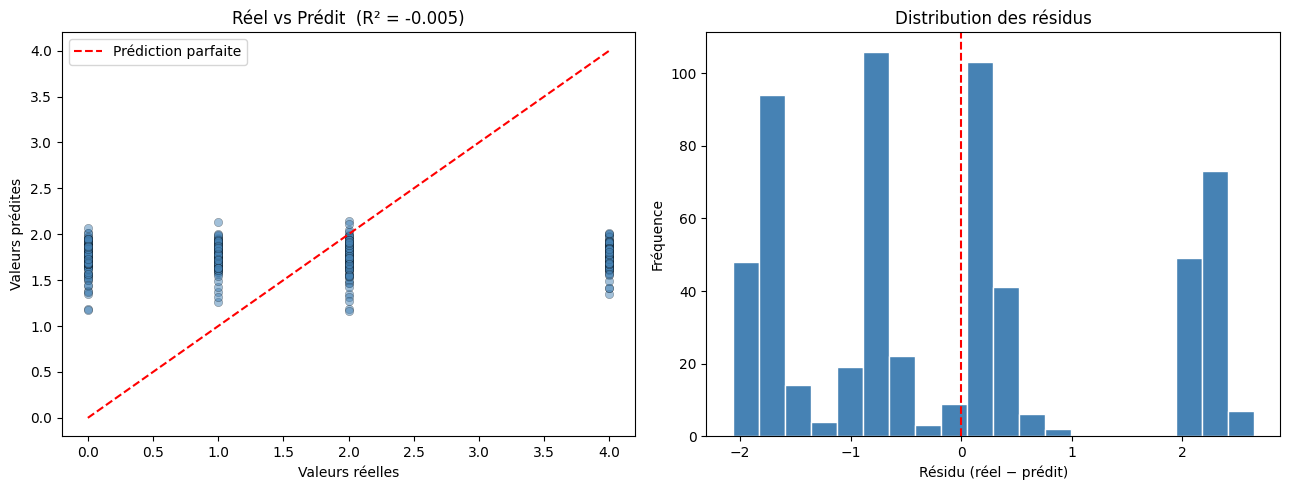

Résidu moyen : -0.1127
Écart-type   : 1.4316


In [24]:
best_rf = resultats['Random Forest']['model']
y_pred  = best_rf.predict(X_test)
r2_opt  = resultats['Random Forest']['optimized']['r2']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# reel vs predit
axes[0].scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='k', linewidths=0.3)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=1.5, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles')
axes[0].set_ylabel('Valeurs prédites')
axes[0].set_title(f'Réel vs Prédit  (R² = {r2_opt:.3f})')
axes[0].legend()

# distribution résidus
residus = y_test - y_pred
axes[1].hist(residus, bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Résidu (réel − prédit)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution des résidus')

plt.tight_layout()
plt.show()

print(f"Résidu moyen : {residus.mean():.4f}")
print(f"Écart-type   : {residus.std():.4f}")

## 8. Exemple d'application

On crée un profil d'étudiant fictif et on demande au modèle de prédire son score d'addiction.  
Les variables catégorielles sont encodées avec les mêmes `LabelEncoder` utilisés à l'étape 2.

In [26]:
# exeple d'un étudiant fictif
etudiant = {
    'Country'                      : 'USA',
    'Age'                          : 20,
    'Gender'                       : 'Male',
    'Occupation'                   : 'Student',
    'Education_Level'              : 'High School',
    'Income_USD'                    : 15000,
    'Daily_Social_Media_Usage_Hours' : 5.0,
    'Phone_Unlocked_Per_Day'           : 50,
    'Social_Media_Usage_Hours_Per_Day'       : 4.0,
    'Gaming_Usage_Hours'                : 1.0,
    'Streaming_Usage_Hours'              : 0.5,
    'Messaging_Usage_Hours'             : 0.5,
    'Work_Related_Usage_Hours'             : 0.0,
    'Sleep_Hours'                 : 6.0,
    'Physical_Activity_Hours'     : 1.0,
    'Mental_Health_Score'         : 13.0,
    'Depression_Score'          : 20.0,
    'Anxiety_Score'             : 15.0,
    'Stress_Level'              : 18.0,
    'Relathionship_status'         : 'Single',
    'Has_Children'                 : 'No',
    'Urban_or_Rural'              : 'Urban',
    'Time_Spent_With_Family_Hours_Per_Day' : 1.0,
    'Online_Shopping_Hours' : 0.5,
    'Internet_Connection_Type' : 'WiFi',
    'Primary_Device_Brand' : 'Apple',
    'Has_Screen_Time_Managment_App' : 'No',
    'Monthly_Data_Usage_GB' : 10.0,
    'Has_Night_Mode_On' : 'Yes',
    'Age_First_Phone' : 12,
    'Push_Notifications_Per_Day' : 30,
    'Tech_Savviness_Score' : 7.0,
    'Addiction_screen' : 1.0,

}

# encodage
etudiant_enc = {}
for col, val in etudiant.items():
    if col in label_encoders:
        etudiant_enc[col] = label_encoders[col].transform([val])[0]
    else:
        etudiant_enc[col] = val

X_etudiant = pd.DataFrame([etudiant_enc])[X.columns]

# prédiction
score_predit = best_rf.predict(X_etudiant)[0]

print("=== Profil de l'étudiant ===")
for k, v in etudiant.items():
    print(f"  {k:<35} : {v}")

print(f"\n Score d'addiction prédit : {score_predit:.2f} / 9")

if score_predit >= 7:
    print("    → Niveau élevé d'addiction")
elif score_predit >= 4:
    print("    → Niveau modéré d'addiction")
else:
    print("    → Niveau faible d'addiction")

ValueError: y contains previously unseen labels: 15000